## Import Libraries & Load Cleaned Data

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('../data/superstore_cleaned.csv')
print("Data loaded!")
print("Shape:", df.shape)

Data loaded!
Shape: (9994, 30)


## Sales by Category

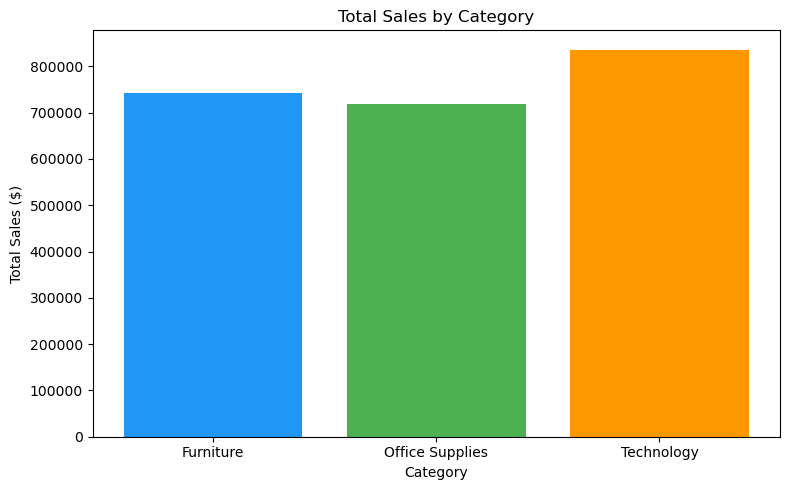

Chart saved!


In [4]:
category_sales = df.groupby('Category')['Sales'].sum().reset_index()

plt.figure(figsize=(8, 5))
plt.bar(category_sales['Category'], category_sales['Sales'], 
        color=['#2196F3','#4CAF50','#FF9800'])
plt.title('Total Sales by Category')
plt.xlabel('Category')
plt.ylabel('Total Sales ($)')
plt.tight_layout()
plt.savefig('../outputs/02_sales_by_category.png')
plt.show()
print("Chart saved!")

## Profit by Region

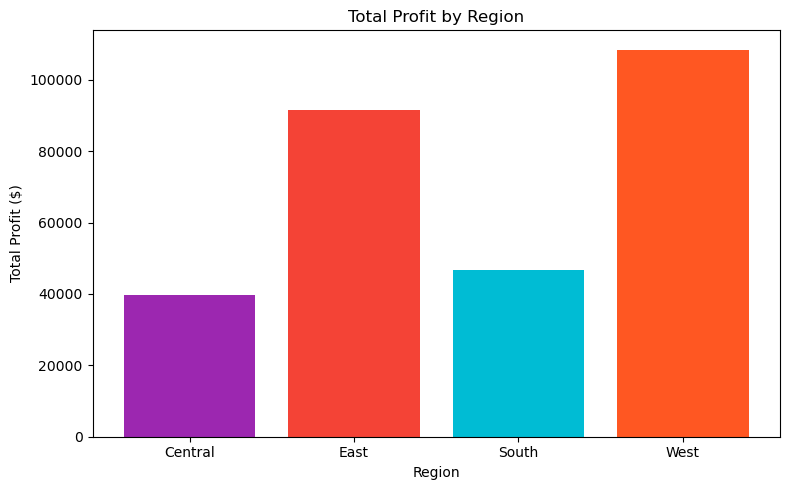

Chart saved!


In [5]:
region_profit = df.groupby('Region')['Profit'].sum().reset_index()

plt.figure(figsize=(8, 5))
plt.bar(region_profit['Region'], region_profit['Profit'],
        color=['#9C27B0','#F44336','#00BCD4','#FF5722'])
plt.title('Total Profit by Region')
plt.xlabel('Region')
plt.ylabel('Total Profit ($)')
plt.tight_layout()
plt.savefig('../outputs/02_profit_by_region.png')
plt.show()
print("Chart saved!")

## Monthly Sales Trend

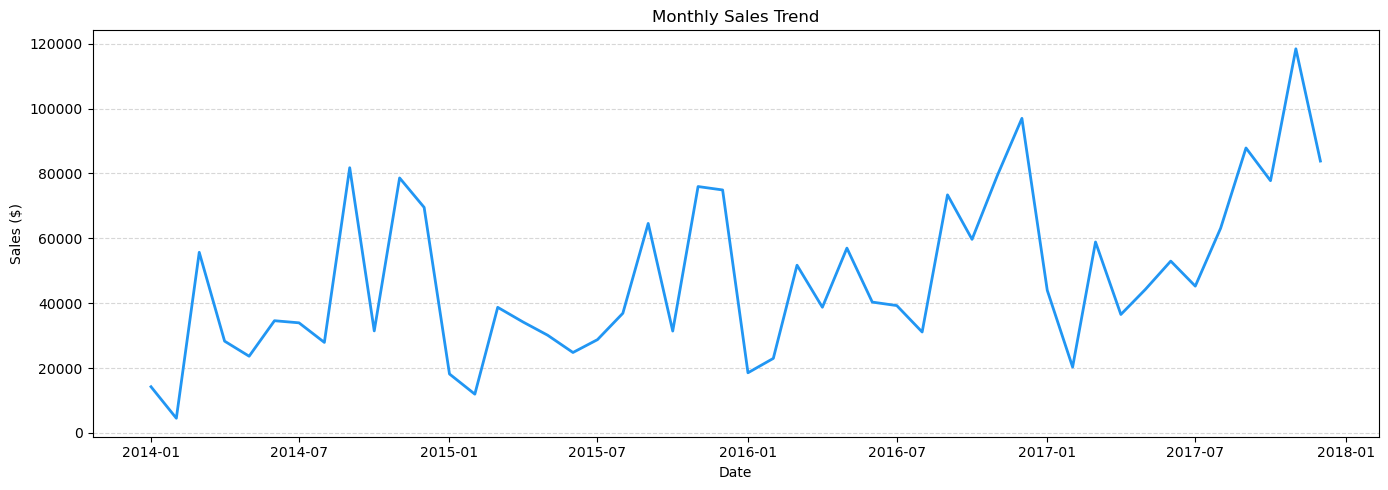

Chart saved!


In [6]:
monthly = df.groupby(['Order Year','Order Month'])['Sales'].sum().reset_index()
monthly['Date'] = pd.to_datetime(monthly[['Order Year','Order Month']].rename(
    columns={'Order Year':'year','Order Month':'month'}).assign(day=1))

plt.figure(figsize=(14, 5))
plt.plot(monthly['Date'], monthly['Sales'], color='#2196F3', linewidth=2)
plt.title('Monthly Sales Trend')
plt.xlabel('Date')
plt.ylabel('Sales ($)')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../outputs/02_monthly_trend.png')
plt.show()
print("Chart saved!")

## Top 10 Sub-Categories by Sales

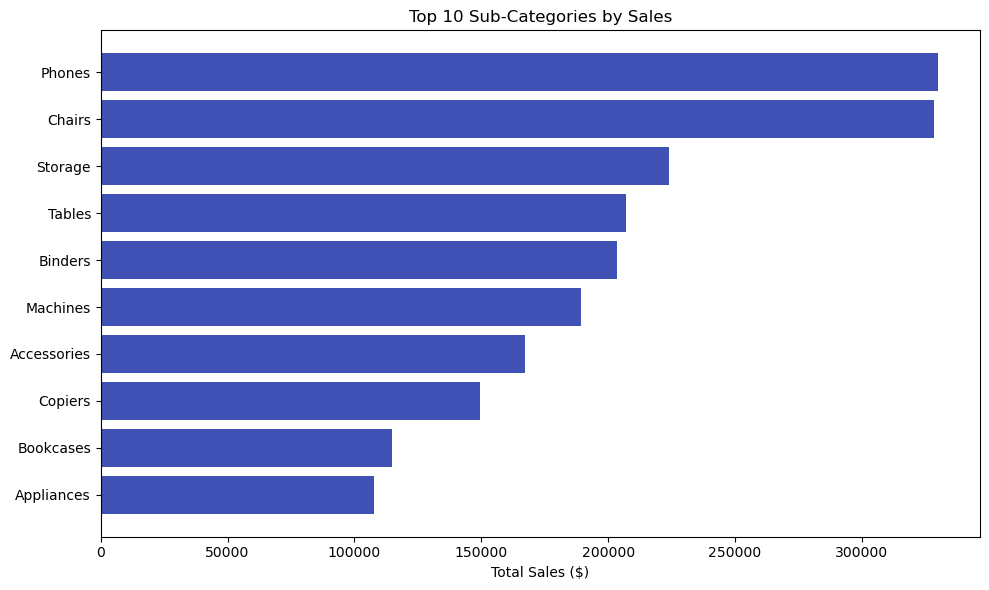

Chart saved!


In [7]:
top_subcat = df.groupby('Sub-Category')['Sales'].sum()\
               .sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10, 6))
plt.barh(top_subcat['Sub-Category'], top_subcat['Sales'], color='#3F51B5')
plt.title('Top 10 Sub-Categories by Sales')
plt.xlabel('Total Sales ($)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('../outputs/02_top_subcategories.png')
plt.show()
print("Chart saved!")

## Loss Making Sub-Categories

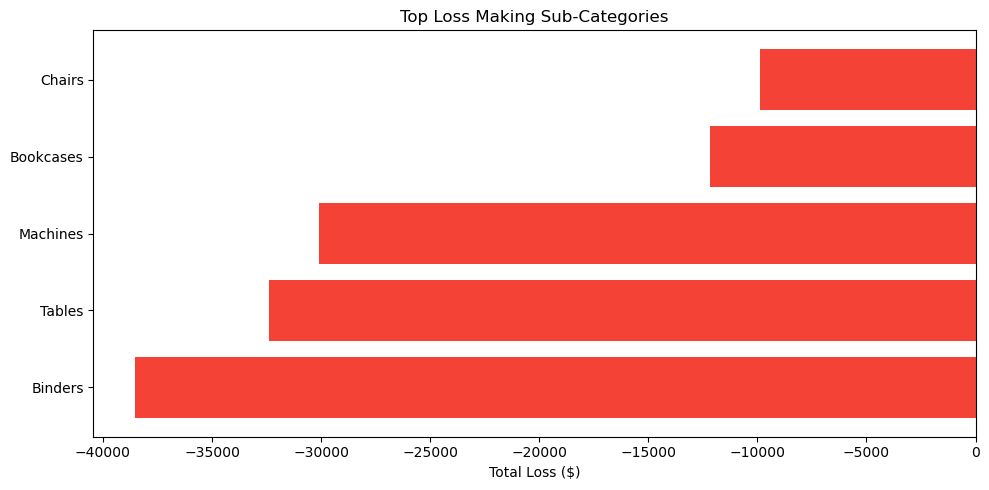

Chart saved!


In [8]:
loss = df[df['Profit'] < 0].groupby('Sub-Category')['Profit']\
        .sum().sort_values().head(5).reset_index()

plt.figure(figsize=(10, 5))
plt.barh(loss['Sub-Category'], loss['Profit'], color='#F44336')
plt.title('Top Loss Making Sub-Categories')
plt.xlabel('Total Loss ($)')
plt.tight_layout()
plt.savefig('../outputs/02_loss_subcategories.png')
plt.show()
print("Chart saved!")

## Sales by Customer Segment

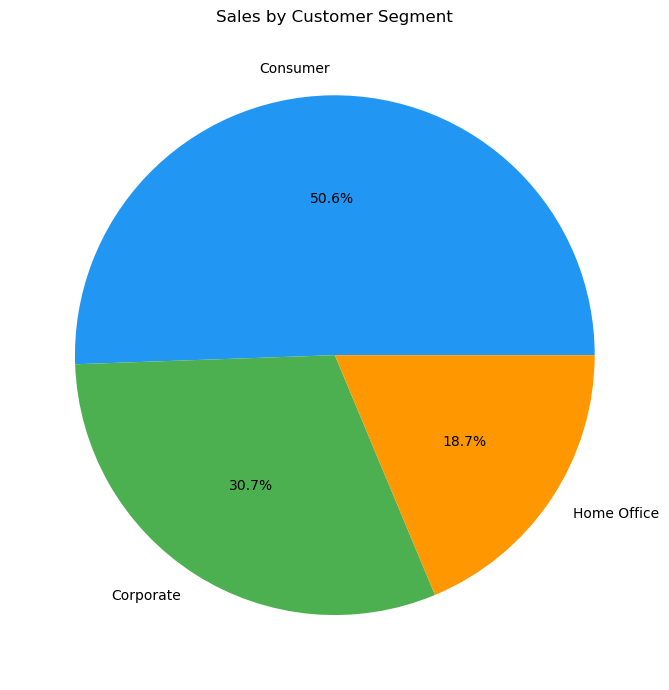

Chart saved!


In [9]:
segment = df.groupby('Segment')['Sales'].sum().reset_index()

plt.figure(figsize=(7, 7))
plt.pie(segment['Sales'], labels=segment['Segment'],
        autopct='%1.1f%%', colors=['#2196F3','#4CAF50','#FF9800'])
plt.title('Sales by Customer Segment')
plt.tight_layout()
plt.savefig('../outputs/02_segment_sales.png')
plt.show()
print("Chart saved!")

## Key Business Insights

In [10]:
print("=" * 50)
print("KEY BUSINESS INSIGHTS")
print("=" * 50)

top_cat    = df.groupby('Category')['Sales'].sum().idxmax()
top_region = df.groupby('Region')['Profit'].sum().idxmax()
low_region = df.groupby('Region')['Profit'].sum().idxmin()
top_seg    = df.groupby('Segment')['Sales'].sum().idxmax()
loss_pct   = round((df['Is Profitable']=='No').sum() / len(df) * 100, 1)
avg_ship   = round(df['Days to Ship'].mean(), 1)
top_sub    = df.groupby('Sub-Category')['Sales'].sum().idxmax()

print(f"\n1. Top Sales Category     : {top_cat}")
print(f"2. Most Profitable Region : {top_region}")
print(f"3. Least Profitable Region: {low_region}")
print(f"4. Top Customer Segment   : {top_seg}")
print(f"5. Loss Transactions      : {loss_pct}%")
print(f"6. Avg Days to Ship       : {avg_ship} days")
print(f"7. Top Sub-Category       : {top_sub}")

KEY BUSINESS INSIGHTS

1. Top Sales Category     : Technology
2. Most Profitable Region : West
3. Least Profitable Region: Central
4. Top Customer Segment   : Consumer
5. Loss Transactions      : 19.4%
6. Avg Days to Ship       : 4.0 days
7. Top Sub-Category       : Phones
